In [36]:
import pandas as pd


In [37]:
df = pd.read_csv('train.csv')

df

In [38]:
df[['day','month','year']] = df['week'].str.split('/',expand=True)

In [39]:
df=df.drop('week' , axis=1)

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X,Y =df.drop('units_sold',axis =1),df['units_sold']
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [41]:
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
model.score(X_test,Y_test)

0.7776162402930871

In [43]:
from sklearn.metrics import root_mean_squared_error
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_pred, Y_test)
rmse

27.012389229107484

In [44]:
df.units_sold.describe()

count    150150.000000
mean         51.674206
std          60.207904
min           1.000000
25%          20.000000
50%          35.000000
75%          62.000000
max        2876.000000
Name: units_sold, dtype: float64

<Axes: >

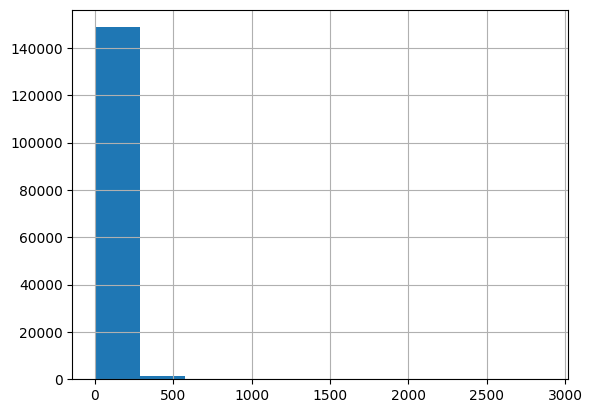

In [45]:
df.units_sold.hist()

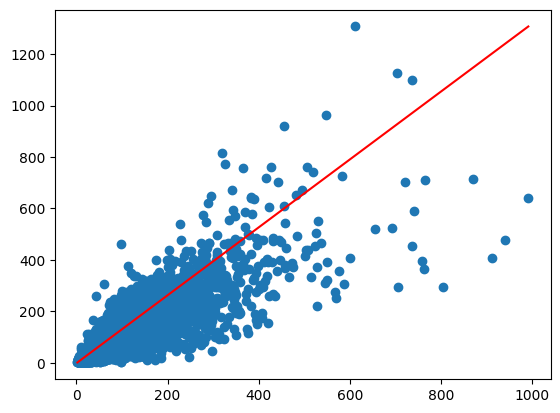

In [46]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(y_pred,Y_test)
plt.plot(np.linspace(y_pred.min(),y_pred.max()),np.linspace(Y_test.min(),Y_test.max()), color='red')

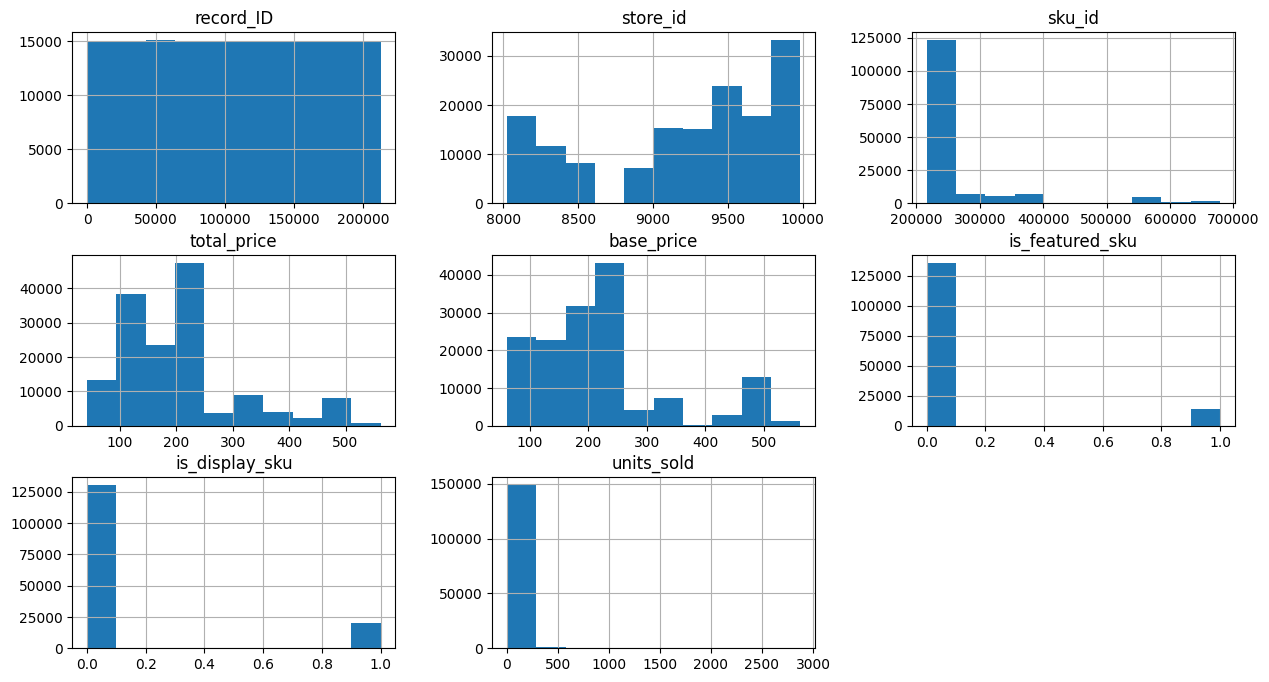

In [47]:
df.hist(figsize=(15,8))
plt.show()

In [48]:
df = df.drop('record_ID',axis=1)

In [49]:
len(df.store_id.unique())

76

In [50]:
len(df.sku_id.unique())

28

In [51]:
df.units_sold.describe()

count    150150.000000
mean         51.674206
std          60.207904
min           1.000000
25%          20.000000
50%          35.000000
75%          62.000000
max        2876.000000
Name: units_sold, dtype: float64

<Axes: >

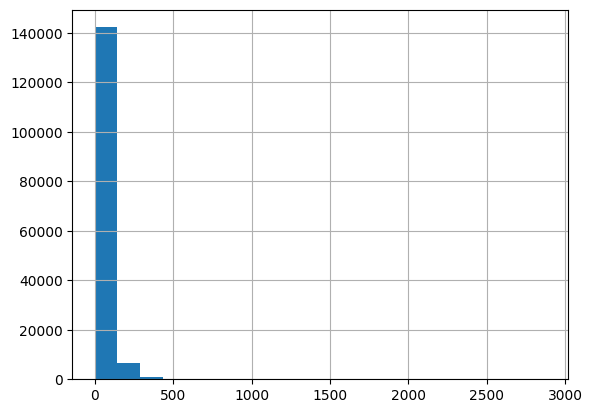

In [52]:
df.units_sold.hist(bins=20)

In [53]:
df=df[df.units_sold < df.units_sold.quantile(0.99)]

<Axes: >

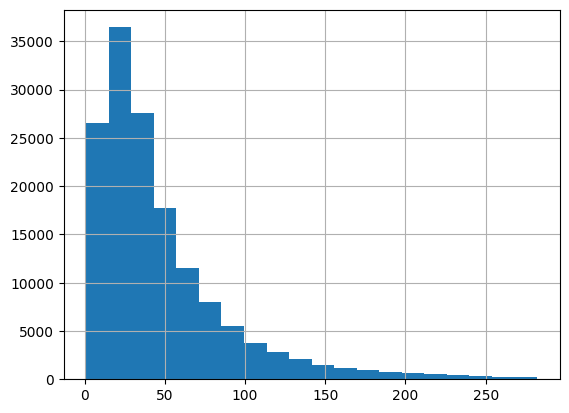

In [54]:
df.units_sold.hist(bins=20)

In [55]:
df.join(pd.get_dummies(df.store_id,prefix='store')).drop('store_id',axis=1)
df.join(pd.get_dummies(df.sku_id,prefix='item')).drop('sku_id',axis=1)

,store_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,item_216233,...,item_320485,item_327492,item_378934,item_398721,item_545621,item_546789,item_547934,item_600934,item_673209,item_679023
0,8091,99.0375,111.8625,0,0,20,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
1,8091,99.0375,99.0375,0,0,28,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
2,8091,133.9500,133.9500,0,0,19,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
3,8091,133.9500,133.9500,0,0,44,17,01,11,True,...,False,False,False,False,False,False,False,False,False,False
4,8091,141.0750,141.0750,0,0,52,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150145,9984,235.8375,235.8375,0,0,38,09,07,13,False,...,False,False,False,False,False,False,False,False,False,False
150146,9984,235.8375,235.8375,0,0,30,09,07,13,False,...,False,False,False,False,False,False,False,False,False,False
150147,9984,357.6750,483.7875,1,1,31,09,07,13,False,...,False,False,False,False,False,False,False,False,False,False
150148,9984,141.7875,191.6625,0,1,12,09,07,13,False,...,False,False,False,False,False,False,True,False,False,False


In [57]:
model=RandomForestRegressor(n_jobs=-1)

x,Y=df.drop('units_sold',axis=1),df['units_sold']
X_train,X_test,Y_train,Y_test = train_test_split(x,Y,test_size=0.2,random_state=42)

In [58]:
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
model.score(X_test,Y_test)

0.8077637685569999

In [60]:
y_pred=model.predict(X_test)
rmse=root_mean_squared_error(y_pred,Y_test)
rmse

18.715706393741552

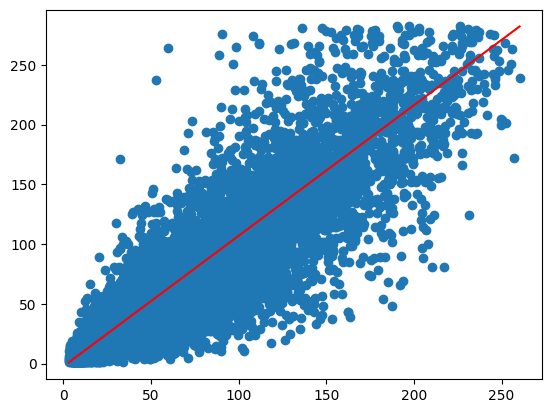

In [61]:
plt.scatter(y_pred,Y_test)
plt.plot(np.linspace(y_pred.min(),y_pred.max()),np.linspace(Y_test.min(),Y_test.max()), color='red')

In [66]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators':[100,150,200],
    'min_samples_split':[2,3]
}

model=RandomForestRegressor(n_jobs=-1)
grid_search = GridSearchCV(model,param_grid,verbose=2,cv=3)
grid_search.fit(x,Y)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ..............min_samples_split=2, n_estimators=100; total time=   5.7s
[CV] END ..............min_samples_split=2, n_estimators=100; total time=   5.9s
[CV] END ..............min_samples_split=2, n_estimators=100; total time=   5.3s
[CV] END ..............min_samples_split=2, n_estimators=150; total time=   7.0s
[CV] END ..............min_samples_split=2, n_estimators=150; total time=   7.0s
[CV] END ..............min_samples_split=2, n_estimators=150; total time=   6.4s
[CV] END ..............min_samples_split=2, n_estimators=200; total time=   8.5s
[CV] END ..............min_samples_split=2, n_estimators=200; total time=   8.3s
[CV] END ..............min_samples_split=2, n_estimators=200; total time=   8.1s
[CV] END ..............min_samples_split=3, n_estimators=100; total time=   3.9s
[CV] END ..............min_samples_split=3, n_estimators=100; total time=   4.1s
[CV] END ..............min_samples_split=3, n_est

,estimator,RandomForestR...sor(n_jobs=-1)
,param_grid,"{'min_samples_split': [2, 3], 'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [67]:
best_model = grid_search.best_estimator_

In [68]:
grid_search.best_params_

{'min_samples_split': 2, 'n_estimators': 200}

In [69]:
best_model.score(X_test,Y_test)

0.9748301749950606